In [ ]:
import os
import cv2
import numpy as np
import librosa
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import librosa
from tensorflow.keras.preprocessing.sequence import pad_sequences

def extract_frames(video_path, num_frames=30):
    try:
        cap = cv2.VideoCapture(video_path)
        frames = []
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frame_interval = max(total_frames // num_frames, 1)

        for i in range(num_frames):
            cap.set(cv2.CAP_PROP_POS_FRAMES, i * frame_interval)
            ret, frame = cap.read()
            if ret:
                frame = cv2.resize(frame, (224, 224))
                frames.append(frame)
            else:
                break

        cap.release()
        if len(frames) == 0:
            raise ValueError("No frames extracted")
        return np.array(frames)
    except Exception as e:
        print(f"Error extracting frames from {video_path}: {e}")
        return None

def extract_audio_features(audio_path, n_mfcc=40, max_pad_len=862):
    try:
        y, sr = librosa.load(audio_path, sr=None)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        if mfcc.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :max_pad_len]
        return mfcc.T
    except Exception as e:
        print(f"Error extracting audio features from {audio_path}: {e}")
        return None

# Paths to dataset
DATASET_PATH = '/content/drive/MyDrive/Capstone/Dataset/Video'
CLASS_NAMES = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

video_data = []
audio_data = []
labels = []

for class_name in CLASS_NAMES:
    class_path = os.path.join(DATASET_PATH, class_name)
    for video_name in os.listdir(class_path):
        video_path = os.path.join(class_path, video_name)
        if not video_name.endswith('.mp4'):
            continue
        frames = extract_frames(video_path)
        audio_features = extract_audio_features(video_path)

        if frames is not None and audio_features is not None:
            video_data.append(frames)
            audio_data.append(audio_features)
            labels.append(CLASS_NAMES.index(class_name))
        else:
            print(f"Skipping {video_name} due to insufficient data")

# Pad video sequences to a uniform length
video_data_padded = pad_sequences(video_data, padding='post', dtype='float32')

audio_data = pad_sequences(audio_data, padding='post', dtype='float32')  # Pad sequences to the same length
labels = np.array(labels)

print("Video data shape:", video_data_padded.shape) # Use the padded video data
print("Audio data shape:", audio_data.shape)
print("Labels shape:", labels.shape)


Streaming output truncated to the last 5000 lines.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
<ipython-input-3-d642dd971d7d>:33: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=None)
/usr/local/lib/python3.10/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
<ipython-input-3-d642dd971d7d>:33: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=None)
/usr/local/lib/python3.10/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
<ipython-input-3-d642dd971

Video data shape: (1035, 30, 224, 224, 3)
Audio data shape: (1035, 862, 40)
Labels shape: (1035,)


In [ ]:
from tensorflow.keras.applications import mobilenet_v2
from tensorflow.keras.models import Model
import tensorflow as tf

# Load pre-trained MobileNetV2 model + higher level layers
base_model = mobilenet_v2.MobileNetV2(include_top=False, input_shape=(224, 224, 3), weights='imagenet') # Call the MobileNetV2 class within the module.
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
video_model = Model(inputs=base_model.input, outputs=x)

# Extract features from each frame set
video_features = []
for frames in video_data:
    features = video_model.predict(frames)
    video_features.append(features.mean(axis=0))  # Average features over frames

video_features = np.array(video_features)
print("Video features shape:", video_features.shape)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1

In [ ]:
from sklearn.model_selection import train_test_split

X_train_video, X_test_video, X_train_audio, X_test_audio, y_train, y_test = train_test_split(
    video_features, audio_data, labels, test_size=0.3, random_state=42)

# Ensure audio data shape compatibility
X_train_audio = np.expand_dims(X_train_audio, -1)
X_test_audio = np.expand_dims(X_test_audio, -1)

print("Train video shape:", X_train_video.shape)
print("Test video shape:", X_test_video.shape)
print("Train audio shape:", X_train_audio.shape)
print("Test audio shape:", X_test_audio.shape)
print("Train labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)

Train video shape: (724, 1280)
Test video shape: (311, 1280)
Train audio shape: (724, 862, 40, 1)
Test audio shape: (311, 862, 40, 1)
Train labels shape: (724,)
Test labels shape: (311,)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, concatenate, Dropout
from tensorflow.keras.regularizers import l2

# Video model - Adjust input shape to match actual video feature dimensions
video_input = Input(shape=(1280,))
video_dense = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(video_input)
video_dropout = Dropout(0.5)(video_dense)

# Audio model
audio_input = Input(shape=(862, 40))
audio_lstm = LSTM(128, kernel_regularizer=l2(0.001))(audio_input)
audio_dropout = Dropout(0.5)(audio_lstm)

# Fusion model
merged = concatenate([video_dropout, audio_dropout])
dense_1 = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(merged)
dense_1_dropout = Dropout(0.5)(dense_1)
output = Dense(len(CLASS_NAMES), activation='softmax')(dense_1_dropout)

fusion_model = Model(inputs=[video_input, audio_input], outputs=output)
fusion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
fusion_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 1280)           │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_4             │ (None, 862, 40)        │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 128)            │        163,968 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_1 (LSTM)             │ (None, 128)            │         86,528 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 128)            │              0 │ dense_3[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_4 (Dropout)       │ (None, 128)            │              0 │ lstm_1[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 256)            │              0 │ dropout_3[0][0],       │
│ (Concatenate)             │                        │                │ dropout_4[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)           │ (None, 128)            │         32,896 │ concatenate_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_5 (Dropout)       │ (None, 128)            │              0 │ dense_4[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_5 (Dense)           │ (None, 7)              │            903 │ dropout_5[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 284,295 (1.08 MB)

 Trainable params: 284,295 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = fusion_model.fit(
    [X_train_video, X_train_audio], y_train,
    validation_data=([X_test_video, X_test_audio], y_test),
    epochs=100, batch_size=32)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.1295 - loss: 2.7445 - val_accuracy: 0.1865 - val_loss: 2.2798
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.1593 - loss: 2.2950 - val_accuracy: 0.1672 - val_loss: 2.1978
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.1991 - loss: 2.1897 - val_accuracy: 0.1801 - val_loss: 2.1625
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.1936 - loss: 2.1542 - val_accuracy: 0.2186 - val_loss: 2.1001
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.2156 - loss: 2.1069 - val_accuracy: 0.2637 - val_loss: 2.0683
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.2063 - loss: 2.0571 - val_accuracy: 0.2219 - val_loss: 2.0121
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.2471 - loss: 2.0151 - val_accuracy: 0.2669 - val_loss: 1.9477
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.2240 - loss: 1.9891 - val_accuracy: 0.

In [ ]:
# Generate classification report
from sklearn.metrics import classification_report
y_pred = np.argmax(fusion_model.predict([X_test_video, X_test_audio]), axis=1)
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
              precision    recall  f1-score   support

       Angry       0.69      0.40      0.51        50
     Disgust       0.46      0.51      0.48        43
        Fear       0.77      0.44      0.56        55
       Happy       0.78      0.78      0.78        45
     Neutral       0.91      1.00      0.95        41
         Sad       0.47      0.75      0.58        36
    Surprise       0.54      0.73      0.62        41

    accuracy                           0.64       311
   macro avg       0.66      0.66      0.64       311
weighted avg       0.67      0.64      0.63       311



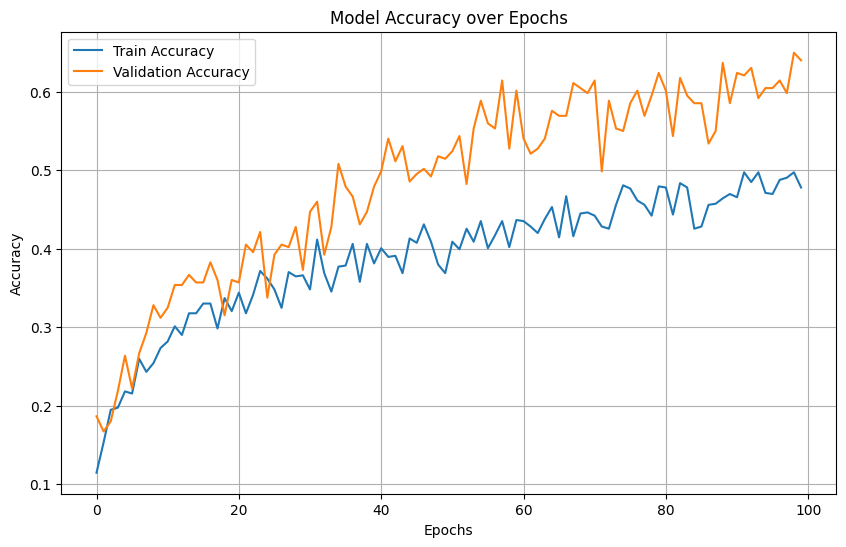

In [ ]:
import matplotlib.pyplot as plt

# Assuming `history` is the History object returned by model.fit()

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()


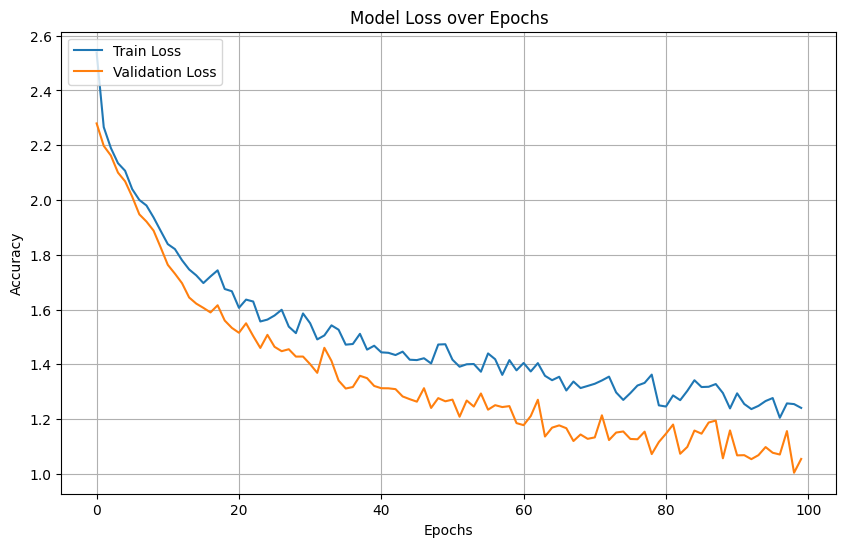

In [ ]:
import matplotlib.pyplot as plt

# Assuming `history` is the History object returned by model.fit()

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()


In [ ]:


from sklearn.metrics import confusion_matrix

# Generate confusion matrix
confusion_matrix = confusion_matrix(y_test, y_pred)

# Print the confusion matrix
print(confusion_matrix)


[[20 16  0  4  0  7  3]
 [ 6 22  0  4  0  9  2]
 [ 0  6 24  0  2  8 15]
 [ 1  1  0 35  0  4  4]
 [ 0  0  0  0 41  0  0]
 [ 2  0  3  2  0 27  2]
 [ 0  3  4  0  2  2 30]]


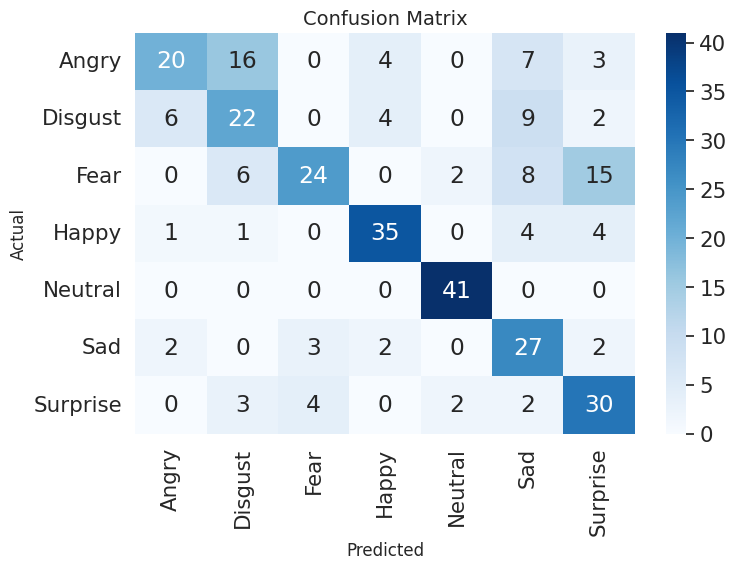

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix # Re-import the function

# Generate confusion matrix using the imported function
cm = confusion_matrix(y_test, y_pred)

# Set up the visualization
sns.set(font_scale=1.4)  # Increase font size
plt.figure(figsize=(8, 6))  # Set figure size

# Create the heatmap using cm
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)

# Add labels and title
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)
plt.tight_layout()  # Improve spacing

# Show the plot
plt.show()


In [ ]:
fusion_model.save('/content/drive/MyDrive/MobileNetfusion_fulldataset.h5')